# writing all the correlation functions manually without AI

what do we need to do:

1- a function to average R and L

# <font color="red"> ============================================================================</font>

In [105]:
import shutil

import numpy as np
import nibabel as nib
import pandas as pd
import os
from typing import List, Tuple, Dict, Any, Union, Optional, Callable, Type
from pathlib import Path
import glob
import shutil
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.signal import resample
from vedo.examples.basic.lightings import style

rcParams["path.simplify"] = True
rcParams["path.simplify_threshold"] = 0.5
# Set the font to Arial
rcParams['font.family'] = 'Arial'
rcParams['svg.fonttype'] = 'none'

from allensdk.core.mouse_connectivity_cache import MouseConnectivityCache
from allensdk.api.queries.ontologies_api import OntologiesApi


import nibabel as nib
import numpy as np
from scipy.spatial.distance import cdist
from scipy import stats
import matplotlib.patches as mpatches

from brainsmash.mapgen.stats import pearsonr, pairwise_r
from brainsmash.mapgen.base import Base
from brainsmash.mapgen.stats import nonparp
from brainsmash.mapgen.eval import base_fit

In [3]:
!cd "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials"

In [4]:
work_dir = "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials"

# <font color="blue"> ==================function to average R and L==================</font>

In [5]:
avg_TA_tsv = f"{work_dir}/average_regional_TA.tsv"

In [6]:
avg_TA_df = pd.read_csv(avg_TA_tsv, sep="\t")

In [7]:
avg_TA_df.head()

,index,name,regional_TA
0,1,"L_Frontal pole, cerebral cortex",0.016979
1,2,"R_Frontal pole, cerebral cortex",0.071766
2,3,L_Somatomotor areas,0.079046
3,4,R_Somatomotor areas,0.073707
4,5,L_Somatosensory areas,0.054773


In [8]:
# average each two consuecutive rows (R and L) and create a new dataf
# mae a new column
avg_TA_df['bilateral_region'] = avg_TA_df['name'].str.replace('R_', '').str.replace('L_', '')

In [9]:
avg_TA_df

,index,name,regional_TA,bilateral_region
0,1,"L_Frontal pole, cerebral cortex",0.016979,"Frontal pole, cerebral cortex"
1,2,"R_Frontal pole, cerebral cortex",0.071766,"Frontal pole, cerebral cortex"
2,3,L_Somatomotor areas,0.079046,Somatomotor areas
3,4,R_Somatomotor areas,0.073707,Somatomotor areas
4,5,L_Somatosensory areas,0.054773,Somatosensory areas
...,...,...,...,...
97,98,R_Vermal regions,0.098506,Vermal regions
98,99,L_Hemispheric regions,0.070709,Hemispheric regions
99,100,R_Hemispheric regions,0.219860,Hemispheric regions
100,101,L_Cerebellar nuclei,-0.009284,Cerebellar nuclei


In [10]:
# average regional_TA rows with the same region name and add the value to a new column named "bilateral_TA" and duplicate it for each row
avg_TA_df['bilateral_TA'] = avg_TA_df.groupby('bilateral_region')['regional_TA'].transform('mean')

In [11]:
avg_TA_df

,index,name,regional_TA,bilateral_region,bilateral_TA
0,1,"L_Frontal pole, cerebral cortex",0.016979,"Frontal pole, cerebral cortex",0.044373
1,2,"R_Frontal pole, cerebral cortex",0.071766,"Frontal pole, cerebral cortex",0.044373
2,3,L_Somatomotor areas,0.079046,Somatomotor areas,0.076376
3,4,R_Somatomotor areas,0.073707,Somatomotor areas,0.076376
4,5,L_Somatosensory areas,0.054773,Somatosensory areas,0.093441
...,...,...,...,...,...
97,98,R_Vermal regions,0.098506,Vermal regions,0.079375
98,99,L_Hemispheric regions,0.070709,Hemispheric regions,0.145285
99,100,R_Hemispheric regions,0.219860,Hemispheric regions,0.145285
100,101,L_Cerebellar nuclei,-0.009284,Cerebellar nuclei,-0.006288


In [12]:
# now keep only unique rows based on the bilateral_region column and keep only the bilateral_TA column
avg_TA_df = avg_TA_df.drop_duplicates(subset=['bilateral_region'])

In [13]:
avg_TA_df

,index,name,regional_TA,bilateral_region,bilateral_TA
0,1,"L_Frontal pole, cerebral cortex",0.016979,"Frontal pole, cerebral cortex",0.044373
2,3,L_Somatomotor areas,0.079046,Somatomotor areas,0.076376
4,5,L_Somatosensory areas,0.054773,Somatosensory areas,0.093441
6,7,L_Gustatory areas,-0.001614,Gustatory areas,0.023168
8,9,L_Visceral area,0.009943,Visceral area,0.004315
10,11,L_Auditory areas,0.014780,Auditory areas,0.061381
12,13,L_Visual areas,0.066705,Visual areas,0.085340
14,15,L_Anterior cingulate area,0.021002,Anterior cingulate area,0.038738
16,17,L_Prelimbic area,-0.010282,Prelimbic area,-0.006479
18,19,L_Infralimbic area,0.020489,Infralimbic area,0.014348


In [14]:
avg_TA_bilateral = avg_TA_df[['index', 'bilateral_region', 'bilateral_TA']]

In [15]:
avg_TA_bilateral

,index,bilateral_region,bilateral_TA
0,1,"Frontal pole, cerebral cortex",0.044373
2,3,Somatomotor areas,0.076376
4,5,Somatosensory areas,0.093441
6,7,Gustatory areas,0.023168
8,9,Visceral area,0.004315
10,11,Auditory areas,0.061381
12,13,Visual areas,0.085340
14,15,Anterior cingulate area,0.038738
16,17,Prelimbic area,-0.006479
18,19,Infralimbic area,0.014348


In [16]:
# encapsulate the above code in a function that takes the input tsv file and output tsv file as arguments
def average_R_L(input_tsv, output_tsv, key_word='regional_TA'):
    avg_metric_df = pd.read_csv(input_tsv, sep="\t")

    # remove row with index 0 if it exists (for the LSFM data, the index 0 is the background)
    if 0 in avg_metric_df['index'].values:
        avg_metric_df = avg_metric_df[avg_metric_df['index'] != 0]
    # somehow in the LSFM tsv the "," got replaced with "\t", so we need to replace it back
    avg_metric_df['name'] = avg_metric_df['name'].str.replace('\t ', ', ', regex=False)

    avg_metric_df['bilateral_region'] = avg_metric_df['name'].str.replace('R_', '').str.replace('L_', '')
    avg_metric_df[f'{key_word}_bilateral'] = avg_metric_df.groupby('bilateral_region')[key_word].transform('mean')
    avg_metric_df = avg_metric_df.drop_duplicates(subset=['bilateral_region'])
    avg_metric_bilateral = avg_metric_df[['index', 'bilateral_region', f'{key_word}_bilateral']].reset_index(drop=True)
    # set the  'bilateral_region' column as str
    avg_metric_bilateral['bilateral_region'] = avg_metric_bilateral['bilateral_region'].astype(str)
    avg_metric_bilateral.to_csv(output_tsv, sep="\t", index=False)
    return avg_metric_bilateral

In [17]:
input_tsv = f"{work_dir}/average_regional_TA.tsv"
output_tsv = f"{work_dir}/average_regional_TA_bilateral.tsv"
TA_df = average_R_L(input_tsv, output_tsv)

In [18]:
TA_df

,index,bilateral_region,regional_TA_bilateral
0,1,"Frontal pole, cerebral cortex",0.044373
1,3,Somatomotor areas,0.076376
2,5,Somatosensory areas,0.093441
3,7,Gustatory areas,0.023168
4,9,Visceral area,0.004315
5,11,Auditory areas,0.061381
6,13,Visual areas,0.085340
7,15,Anterior cingulate area,0.038738
8,17,Prelimbic area,-0.006479
9,19,Infralimbic area,0.014348


In [19]:
input_tsv = f"{work_dir}/sub-hM8362324086031084M5_sample-brain_acq-imaris_seg-mid_from-ABAv3_desc-th800_mergedsegstats.tsv"
output_tsv = f"{work_dir}/sub-hM8362324086031084M5_sample-brain_acq-imaris_seg-mid_from-ABAv3_desc-th800_mergedsegstats_bilateral.tsv"

In [20]:
sync_df = average_R_L(input_tsv, output_tsv, key_word='aSync+fieldfrac')

In [21]:
sync_df

,index,bilateral_region,aSync+fieldfrac_bilateral
0,1,"Frontal pole, cerebral cortex",4.400153
1,3,Somatomotor areas,1.884467
2,5,Somatosensory areas,1.785349
3,7,Gustatory areas,0.531269
4,9,Visceral area,0.508490
5,11,Auditory areas,2.558514
6,13,Visual areas,2.421920
7,15,Anterior cingulate area,0.504088
8,17,Prelimbic area,1.245451
9,19,Infralimbic area,0.135946


In [22]:
# check if the bialteral_region column in the two dataframes are the same
sync_df['bilateral_region'].equals(TA_df['bilateral_region'])

True

# <font color="turquoise"> ============================================================================

# <font color="blue"> ==================function to keep only right hemisphere and only matched regions to struc conn==================</font>

to correlate with functiuonal conn, i want to create a fucntion that takes the tsv with both hemispheres, keep the r hemi pnly and another pone to keep jsut the structures that matches structrual conn

In [23]:
R_L_TA = f"{work_dir}/average_regional_TA.tsv"

In [24]:
# read the tsv file
R_L_TA_df = pd.read_csv(R_L_TA, sep="\t")

In [25]:
R_L_TA_df

,index,name,regional_TA
0,1,"L_Frontal pole, cerebral cortex",0.016979
1,2,"R_Frontal pole, cerebral cortex",0.071766
2,3,L_Somatomotor areas,0.079046
3,4,R_Somatomotor areas,0.073707
4,5,L_Somatosensory areas,0.054773
...,...,...,...
97,98,R_Vermal regions,0.098506
98,99,L_Hemispheric regions,0.070709
99,100,R_Hemispheric regions,0.219860
100,101,L_Cerebellar nuclei,-0.009284


In [26]:
R_TA_df = R_L_TA_df[R_L_TA_df['name'].str.startswith('R_')].reset_index(drop=True)

In [27]:
R_TA_df

,index,name,regional_TA
0,2,"R_Frontal pole, cerebral cortex",0.071766
1,4,R_Somatomotor areas,0.073707
2,6,R_Somatosensory areas,0.132109
3,8,R_Gustatory areas,0.047949
4,10,R_Visceral area,-0.001313
5,12,R_Auditory areas,0.107982
6,14,R_Visual areas,0.103975
7,16,R_Anterior cingulate area,0.056475
8,18,R_Prelimbic area,-0.002676
9,20,R_Infralimbic area,0.008207


In [28]:
# we just use the exact same function as above but we will add a new argument to keep only the right hemisphere
# encapsulate the above code in a function that takes the input tsv file and output tsv file as arguments
def process_regional_metrics(input_tsv: str,
                output_dir: Optional[str] = None,
                output_tsv_stem: Optional[str] = None,
                key_word:str = 'regional_TA',
    ):
    """A function to process a TSV file containing regional metrics, averaging left and right hemisphere values, and creating filtered outputs.
    example usage:
    >>> process_regional_metrics(input_tsv="/path/to/input.tsv",
                    output_dir="/path/to/output",
                    output_tsv_stem="output_stem",
                    key_word="regional_TA")

    >>> process_regional_metrics(input_tsv="/path/to/input.tsv",
                    key_word="aSync+fieldfrac")


    """

    # read the input tsv file
    avg_metric_df = pd.read_csv(input_tsv, sep="\t")
    output_dir = output_dir or Path(input_tsv).parent
    output_tsv_stem = output_tsv_stem or Path(input_tsv).stem

    # --------------------------------------------
    # 1- clean the data
    # remove row with index 0 if it exists (for the LSFM data, the index 0 is the background)
    if 0 in avg_metric_df['index'].values:
        avg_metric_df = avg_metric_df[avg_metric_df['index'] != 0]

    # somehow in the LSFM tsv the "," got replaced with "\t", so we need to replace it back
    avg_metric_df['name'] = avg_metric_df['name'].str.replace('\t ', ', ', regex=False)

    # --------------------------------------------
    # 2- create a tsv with the right hemisphere only to correlate with stru conn
    # extract the right hemisphere rows only
    avg_metric_df_R = avg_metric_df[avg_metric_df['name'].str.startswith('R_')].reset_index(drop=True)

    # drop the 'index' column and reset the index if it exists
    if 'index' in avg_metric_df_R.columns:
        avg_metric_df_R = avg_metric_df_R.drop(columns=['index']).reset_index(drop=True)


    # save the right hemisphere tsv
    avg_metric_df_R.to_csv(f"{output_dir}/{output_tsv_stem}_R.tsv", sep="\t", index=False)
    print("Right hemisphere tsv saved to: ", f"{output_dir}/{output_tsv_stem}_R.tsv")

    # --------------------------------------------
    # 3- create a tsv with the right hemisphere that matches the remaining in stuc conn after removing false positives to correlate with stru conn
    # keep only the ones that are in the structural conn tsv filtered file
    stru_conn_tsv = "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/stru-func_correlations/conn_mats/CP_avg_conn_right_positive_str_log10.tsv"
    stru_conn_tsv_df = pd.read_csv(stru_conn_tsv, sep="\t")
    avg_metric_df_R_stru_conn = avg_metric_df_R[avg_metric_df_R['name'].isin(stru_conn_tsv_df['name'])].reset_index(drop=True)

    # save the right hemisphere tsv filtered by structural conn
    avg_metric_df_R_stru_conn.to_csv(f"{output_dir}/{output_tsv_stem}_R_stru_conn.tsv", sep="\t", index=False)
    print("Right hemisphere tsv filtered by structural conn saved to: ", f"{output_dir}/{output_tsv_stem}_R_stru_conn.tsv")

    # --------------------------------------------
    # 4- create a tsv with the r and l averaged for each region to correlate with other measures like TA and sync field fraction
    # make a new column for the bilateral region name by removing the R_ and L_ prefixes
    avg_metric_df['bilateral_region'] = avg_metric_df['name'].str.replace(r'^[RL]_', '', regex=True)
    avg_metric_df[f'{key_word}_bilateral'] = avg_metric_df.groupby('bilateral_region')[key_word].transform('mean')
    avg_metric_df = avg_metric_df.drop_duplicates(subset=['bilateral_region'])
    avg_metric_bilateral = avg_metric_df[['bilateral_region', f'{key_word}_bilateral']].reset_index(drop=True)
    # set the  'bilateral_region' column as str
    avg_metric_bilateral['bilateral_region'] = avg_metric_bilateral['bilateral_region'].astype(str)
    avg_metric_bilateral.to_csv(f"{output_dir}/{output_tsv_stem}_bilateral.tsv", sep="\t", index=False)
    print("Bilateral tsv saved to: ", f"{output_dir}/{output_tsv_stem}_bilateral.tsv")

    # --------------------------------------------

    return avg_metric_df_R, avg_metric_df_R_stru_conn, avg_metric_bilateral

In [29]:
input_tsv = f"{work_dir}/average_regional_TA.tsv"

In [30]:
Path(input_tsv).parent

PosixPath('/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials')

In [31]:
process_regional_metrics("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/stru-func_correlations/functions_trials/sub-hM8362324086031084M5_sample-brain_acq-imaris_seg-mid_from-ABAv3_desc-th800_mergedsegstats.tsv", key_word="aSync+fieldfrac")

Right hemisphere tsv saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials/sub-hM8362324086031084M5_sample-brain_acq-imaris_seg-mid_from-ABAv3_desc-th800_mergedsegstats_R.tsv


FileNotFoundError: [Errno 2] No such file or directory: '/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/conn_mats/CP_avg_conn_right_positive_str_log10.tsv'

# <font color="green"> ============================================================================

# <font color="blue"> ==================function to averge multiple dfs==================</font>

In [32]:
input_tsv1 = f"{work_dir}/sub-hM835603942971011M8_average_regional_TA.tsv"
input_tsv2 = f"{work_dir}/sub-hM836223979691084M1_average_regional_TA.tsv"
input_tsv3 = f"{work_dir}/sub-hM836323993941035M4_average_regional_TA.tsv"

input_list = [input_tsv1, input_tsv2, input_tsv3]

In [33]:
# load the three tsv files into three dataframes
dfs = [pd.read_csv(f, sep="\t") for f in input_list]

In [34]:
dfs[0].head()

,index,name,regional_TA
0,1,"L_Frontal pole, cerebral cortex",0.000827
1,2,"R_Frontal pole, cerebral cortex",-0.044832
2,3,L_Somatomotor areas,0.070014
3,4,R_Somatomotor areas,0.103564
4,5,L_Somatosensory areas,0.046136


In [35]:
df_all = pd.concat(dfs)

In [36]:

df_all

,index,name,regional_TA
0,1,"L_Frontal pole, cerebral cortex",0.000827
1,2,"R_Frontal pole, cerebral cortex",-0.044832
2,3,L_Somatomotor areas,0.070014
3,4,R_Somatomotor areas,0.103564
4,5,L_Somatosensory areas,0.046136
...,...,...,...
97,98,R_Vermal regions,0.173083
98,99,L_Hemispheric regions,0.111436
99,100,R_Hemispheric regions,0.189750
100,101,L_Cerebellar nuclei,0.049262


In [37]:
df_all = df_all.groupby('name', sort=False)[["regional_TA"]].mean().reset_index()

In [38]:
df_all.tail()

,name,regional_TA
97,R_Vermal regions,0.103297
98,L_Hemispheric regions,0.082701
99,R_Hemispheric regions,0.125062
100,L_Cerebellar nuclei,0.024516
101,R_Cerebellar nuclei,0.009235


In [39]:
dfs[0].tail()

,index,name,regional_TA
97,98,R_Vermal regions,0.054510
98,99,L_Hemispheric regions,0.038335
99,100,R_Hemispheric regions,0.058564
100,101,L_Cerebellar nuclei,0.027249
101,102,R_Cerebellar nuclei,0.003252


In [40]:
dfs[1].tail()

,index,name,regional_TA
97,98,R_Vermal regions,0.082299
98,99,L_Hemispheric regions,0.098333
99,100,R_Hemispheric regions,0.126872
100,101,L_Cerebellar nuclei,-0.002962
101,102,R_Cerebellar nuclei,0.018687


In [41]:
dfs[2].tail()

,index,name,regional_TA
97,98,R_Vermal regions,0.173083
98,99,L_Hemispheric regions,0.111436
99,100,R_Hemispheric regions,0.189750
100,101,L_Cerebellar nuclei,0.049262
101,102,R_Cerebellar nuclei,0.005765


In [42]:
# wrap into a function
def average_multiple_dfs(input_list: List[str],
                         output_dir: Optional[str] = None,
                         output_tsv_stem: Optional[str] = None,
                         group_by_col: str = 'name',
                         key_word: str = 'regional_TA'):
    """A function to average multiple TSV files containing regional metrics, averaging left and right hemisphere values, and creating filtered outputs.
    example usage:
    >>> average_multiple_dfs(input_list=["/path/to/input1.tsv", "/path/to/input2.tsv", "/path/to/input3.tsv"],
                    output_dir="/path/to/output",
                    output_tsv_stem="output_stem",
                    key_word="regional_TA")

    """
    # load the tsv files into dataframes
    dfs = [pd.read_csv(f, sep="\t") for f in input_list]
    # concatenate the dataframes
    df_all = pd.concat(dfs)
    # average the dataframes by the 'name' column
    df_all = df_all.groupby(group_by_col, sort=False)[[key_word]].mean().reset_index()
    # save the averaged dataframe to a tsv file
    output_dir = output_dir or Path(input_list[0]).parent
    output_tsv_stem = output_tsv_stem or "average_multiple_dfs"
    df_all.to_csv(f"{output_dir}/{output_tsv_stem}.tsv", sep="\t", index=False)
    print("Averaged tsv saved to: ", f"{output_dir}/{output_tsv_stem}.tsv")
    return df_all

In [43]:
average_multiple_dfs([f"{work_dir}/sub-hM835603942971011M8_average_regional_TA.tsv",
                     f"{work_dir}/sub-hM836223979691084M1_average_regional_TA.tsv",
                     f"{work_dir}/sub-hM836323993941035M4_average_regional_TA.tsv"])

Averaged tsv saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials/average_multiple_dfs.tsv


,name,regional_TA
0,"L_Frontal pole, cerebral cortex",0.004227
1,"R_Frontal pole, cerebral cortex",0.012495
2,L_Somatomotor areas,0.082261
3,R_Somatomotor areas,0.079283
4,L_Somatosensory areas,0.067916
...,...,...
97,R_Vermal regions,0.103297
98,L_Hemispheric regions,0.082701
99,R_Hemispheric regions,0.125062
100,L_Cerebellar nuclei,0.024516


In [44]:
average_multiple_dfs([f"{work_dir}/average_multiple_dfs.tsv",
                     f"{work_dir}/average_multiple_dfs.tsv",
                     f"{work_dir}/average_multiple_dfs.tsv"],
                     output_tsv_stem="average_multiple_dfs_trial",)

Averaged tsv saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials/average_multiple_dfs_trial.tsv


,name,regional_TA
0,"L_Frontal pole, cerebral cortex",0.004227
1,"R_Frontal pole, cerebral cortex",0.012495
2,L_Somatomotor areas,0.082261
3,R_Somatomotor areas,0.079283
4,L_Somatosensory areas,0.067916
...,...,...
97,R_Vermal regions,0.103297
98,L_Hemispheric regions,0.082701
99,R_Hemispheric regions,0.125062
100,L_Cerebellar nuclei,0.024516


# <font color="green"> ============================================================================

# <font color="blue"> ==================function to get the RGB color vector for each region==================</font>

In [45]:
# get the colors of any region based on the name
mcc = MouseConnectivityCache(manifest_file=Path("/tmp") / 'manifest.json', )
structure_tree = mcc.get_structure_tree()

In [46]:
np.array(structure_tree.get_structures_by_name(["Anterior cingulate area"]))[0]

{'acronym': 'ACA',
 'graph_id': 1,
 'graph_order': 220,
 'id': 31,
 'name': 'Anterior cingulate area',
 'structure_id_path': [997, 8, 567, 688, 695, 315, 31],
 'structure_set_ids': [3, 112905828, 691663206, 12, 184527634, 114512891],
 'rgb_triplet': [64, 166, 102]}

In [47]:
np.array(structure_tree.get_structures_by_name(["Ammon's horn"]))[0]

{'acronym': 'CA',
 'graph_id': 1,
 'graph_order': 456,
 'id': 375,
 'name': "Ammon's horn",
 'structure_id_path': [997, 8, 567, 688, 695, 1089, 1080, 375],
 'structure_set_ids': [3,
  112905828,
  691663206,
  12,
  184527634,
  112905813,
  114512891,
  114512892],
 'rgb_triplet': [126, 208, 75]}

In [48]:
structure = "Olfactory areas"
id_path = np.array(structure_tree.get_structures_by_name([structure]))[0]['structure_id_path']
print(id_path)

[997, 8, 567, 688, 695, 698]


In [49]:
np.array(structure_tree.get_structures_by_id([id_path[-2]]))[0]

{'acronym': 'CTXpl',
 'graph_id': 1,
 'graph_order': 4,
 'id': 695,
 'name': 'Cortical plate',
 'structure_id_path': [997, 8, 567, 688, 695],
 'structure_set_ids': [112905828,
  691663206,
  12,
  184527634,
  112905813,
  114512891,
  114512892],
 'rgb_triplet': [112, 255, 112]}

In [50]:

for sid in reversed(id_path):
    s = structure_tree.get_structures_by_id([sid])[0]
    if 2 in s['structure_set_ids']:
        print(f"{s['acronym']} ({sid}) has 2 in structure_set_ids")
        break  # stop at first match

OLF (698) has 2 in structure_set_ids


In [51]:
np.array(structure_tree.get_structures_by_name(["Anterior cingulate area"])[0]["rgb_triplet"]) / 255.0


array([0.25098039, 0.65098039, 0.4       ])

In [52]:
def get_rgb_color_vector(input_tsv_file,
                         major_divisions: Optional[bool] = None):
    """A function to get the RGB color vector for each region in a TSV file based on the Allen Brain Atlas structure tree.
    example usage:
    >>> get_rgb_color_vector(input_tsv_file="/path/to/input.tsv")

    """
    # read the tsv file into a dataframe
    df = pd.read_csv(input_tsv_file, sep="\t")
    # get the structure tree
    mcc = MouseConnectivityCache(manifest_file=Path("/tmp") / 'manifest.json', )
    structure_tree = mcc.get_structure_tree()
    # get the RGB color vector for each region in the dataframe
    rgb_colors = []
    col = [c for c in ["bilateral_region", "region"] if c in df.columns][0]
    df[col] = df[col].str.replace(r'^[RL]_', '', regex=True)

    legend_names = []

    if major_divisions:
        for region in df[col]:
            try:
                id_path = structure_tree.get_structures_by_name([region])[0]['structure_id_path']
                for sid in reversed(id_path): # i want the first one that has 2 in the structure_set_ids from the top level to the bottom level
                    s = structure_tree.get_structures_by_id([sid])[0]
                    if 2 in s['structure_set_ids']:
                        # print(f"{s['acronym']} ({sid}) has 2 in structure_set_ids")
                        break
                major_division_id = sid
                major_division_name = structure_tree.get_structures_by_id([major_division_id])[0]['name']
                rgb_color = np.array(structure_tree.get_structures_by_id([major_division_id])[0]["rgb_triplet"]) / 255.0

                legend_names.append(major_division_name)
            except IndexError:
                rgb_color = np.array([0, 0, 0])
            rgb_colors.append(rgb_color)


    else:
        for region in df["bilateral_region"]:
            try:
                rgb_color = np.array(structure_tree.get_structures_by_name([region])[0]["rgb_triplet"]) / 255.0
                region_name = structure_tree.get_structures_by_name([region])[0]['name']
                legend_names.append(region_name)
            except IndexError:
                rgb_color = np.array([0, 0, 0])

            rgb_colors.append(rgb_color)
    seen = {}
    for name, color in zip(legend_names, rgb_colors):
        if name not in seen:
            seen[name] = color

    legend_names = list(seen.keys())
    legend_colors = np.array(list(seen.values()))
    return np.array(rgb_colors, dtype=float), legend_names, legend_colors

In [53]:
get_rgb_color_vector("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials/average_regional_TA_bilateral.tsv", major_divisions=True)

(array([[0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.43921569, 1.        , 0.44313725],
        [0.60392157, 0.82352941, 0.74117647],
        [0.49411765, 0.81568627, 0.29411765],
        [0.49411765, 0.81568627, 0.29411765],
        [0.49411765, 0.81568627, 0.29411765],
        [0.49411765, 0.81568627, 0

# <font color="blue"> ==================function to correlate columns==================</font>

In [54]:
TA_tsv = f"{work_dir}/average_regional_TA_bilateral.tsv"
sync_tsv = f"{work_dir}/sub-hM8362324086031084M5_sample-brain_acq-imaris_seg-mid_from-ABAv3_desc-th800_mergedsegstats_bilateral.tsv"

In [55]:
# read the tsv files into dataframes
TA_df = pd.read_csv(TA_tsv, sep="\t")
sync_df = pd.read_csv(sync_tsv, sep="\t")

In [56]:
TA_df.head()

,index,bilateral_region,regional_TA_bilateral
0,1,"Frontal pole, cerebral cortex",0.044373
1,3,Somatomotor areas,0.076376
2,5,Somatosensory areas,0.093441
3,7,Gustatory areas,0.023168
4,9,Visceral area,0.004315


In [57]:
sync_df.head()

,index,bilateral_region,aSync+fieldfrac_bilateral
0,1,"Frontal pole, cerebral cortex",4.400153
1,3,Somatomotor areas,1.884467
2,5,Somatosensory areas,1.785349
3,7,Gustatory areas,0.531269
4,9,Visceral area,0.508490


In [58]:
lut_51 = "/Users/aeed/Documents/Work/Allen_Brain_Atlas/CCF_v3/Atlas_res_50_set_id_3/Atlas_res_50_set_id_3_ROIs_51.lut"
lut_51_df = pd.read_csv(lut_51, sep="\t", header=None, names=["index", "R", "G", "B"])

In [59]:
lut_51_df

,index,R,G,B
0,1,0.149020,0.560784,0.270588
1,3,0.121569,0.615686,0.352941
2,5,0.094118,0.501961,0.392157
3,7,0.000000,0.611765,0.458824
4,9,0.066667,0.678431,0.513725
5,11,0.003922,0.576471,0.600000
6,13,0.031373,0.521569,0.549020
7,15,0.250980,0.650980,0.400000
8,17,0.184314,0.658824,0.313725
9,19,0.349020,0.701961,0.388235


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not (array([[0.14901961, 0.56078431, 0.27058824],
       [0.12156863, 0.61568627, 0.35294118],
       [0.09411765, 0.50196078, 0.39215686],
       [0.        , 0.61176471, 0.45882353],
       [0.06666667, 0.67843137, 0.51372549],
       [0.00392157, 0.57647059, 0.6       ],
       [0.03137255, 0.52156863, 0.54901961],
       [0.25098039, 0.65098039, 0.4       ],
       [0.18431373, 0.65882353, 0.31372549],
       [0.34901961, 0.70196078, 0.38823529],
       [0.14117647, 0.54117647, 0.36862745],
       [0.12941176, 0.59607843, 0.4       ],
       [0.10196078, 0.65098039, 0.59607843],
       [0.        , 0.62352941, 0.6745098 ],
       [0.08235294, 0.69019608, 0.70196078],
       [0.05490196, 0.58823529, 0.51764706],
       [0.05098039, 0.62352941, 0.56862745],
       [0.60392157, 0.82352941, 0.74117647],
       [0.49411765, 0.81568627, 0.29411765],
       [0.49411765, 0.81568627, 0.29411765],
     

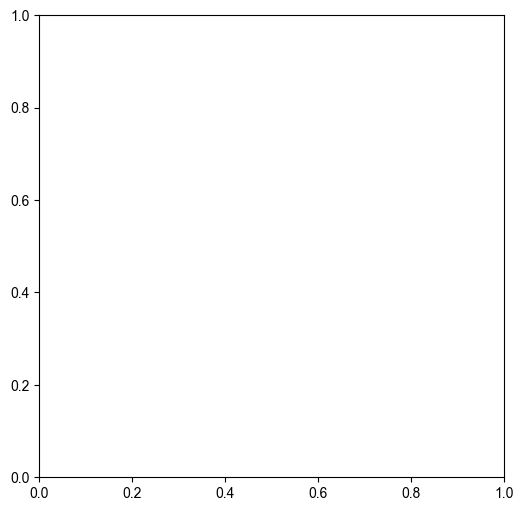

In [60]:
fig, ax = plt.subplots(figsize=(6, 6))


colors = get_rgb_color_vector(TA_tsv)

ax.scatter(TA_df["regional_TA_bilateral"], sync_df["aSync+fieldfrac_bilateral"],
           c=colors,
           s=70,
           alpha=0.7,
           edgecolors="black",
           linewidth=1)

# caclaute the correlation coefficient
corr_coef = np.corrcoef(TA_df["regional_TA_bilateral"], sync_df["aSync+fieldfrac_bilateral"])[0, 1]
# add the correlation coefficient to the plot
ax.text(0.95, 0.95, f"r = {corr_coef:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.set_xlabel("TA")
ax.set_ylabel("Sync Field Fraction")
ax.set_title("Correlation between TA and Sync Field Fraction")

# draw a linear regression line
m, b = np.polyfit(TA_df["regional_TA_bilateral"], sync_df["aSync+fieldfrac_bilateral"], 1)

# plot the regression line
ax.plot(TA_df["regional_TA_bilateral"], m * TA_df["regional_TA_bilateral"] + b,
        color='red',
        linestyle="--",
        linewidth=1)

ax = plt.gca()
# thicker axes and gray color
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('gray')

# thicker ticks
ax.tick_params(width=2, length=6, labelsize=14, colors='gray')

# bold tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# axis labels
ax.set_xlabel('TA', fontsize=16, fontweight='bold')
ax.set_ylabel('field fraction', fontsize=16, fontweight='bold')



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

a# <font color="blue"> ==================now the brainsmash stuff==================</font>

# we need to create the surrgoate maps:

first we need to verify the variogram

then we need to seperate the two hemispheres, geenrate centroid and euclidean vectors for each of them

generate the surrgoate maps then combine them

finally, calcaulte the p value based on the surrogate permutation

In [61]:
atlas_51_bilateral = "/Users/aeed/Documents/Work/Allen_Brain_Atlas/CCF_v3/Atlas_res_50_set_id_3/Atlas_res_50_set_id_3_ROIs_51_bilateral.nii.gz"
atlas_51_bilateral_labels = "/Users/aeed/Documents/Work/Allen_Brain_Atlas/CCF_v3/Atlas_res_50_set_id_3/Atlas_res_50_set_id_3_ROIs_51_bilateral_labels.csv"

In [62]:
# extract labels starting with R_ and L_ from the atlas_51_bilateral_labels file
labels_df = pd.read_csv(atlas_51_bilateral_labels, sep=",")
left_labels = labels_df[labels_df["name"].str.startswith("L_")]["label_value"].values
right_labels = labels_df[labels_df["name"].str.startswith("R_")]["label_value"].values

In [63]:
right_labels

array([  2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,  26,
        28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,  52,
        54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,  78,
        80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100, 102])

In [64]:

atlas = nib.load(atlas_51_bilateral)
data = atlas.get_fdata()
affine = atlas.affine

def get_centroids(label_list, atlas="/Users/aeed/Documents/Work/Allen_Brain_Atlas/CCF_v3/Atlas_res_50_set_id_3/Atlas_res_50_set_id_3_ROIs_51_bilateral.nii.gz"):
    atlas = nib.load(atlas)
    data = atlas.get_fdata()
    centroids = []
    for label in label_list:
        voxels = np.argwhere(data == label)
        centroid_mni = nib.affines.apply_affine(affine, voxels.mean(axis=0))
        centroids.append(centroid_mni)
    return np.array(centroids)

centroids_L = get_centroids(left_labels)
centroids_R = get_centroids(right_labels)

D_L = cdist(centroids_L, centroids_L)
D_R = cdist(centroids_R, centroids_R)

In [65]:
centroids_L

array([[-1.13399933,  3.08082267,  2.44608951],
       [-1.71570476,  1.42224821,  2.99691396],
       [-3.29176652, -0.489984  ,  2.80943565],
       [-3.73462452,  0.68978013,  0.75358583],
       [-4.43442057, -0.95250925,  0.76577002],
       [-4.46655429, -2.50914621,  2.35693403],
       [-2.84354349, -3.64495853,  3.7586812 ],
       [-0.39001373,  0.7384628 ,  3.0431316 ],
       [-0.45124811,  2.24165328,  2.43778989],
       [-0.36738047,  1.85545109,  1.50753759],
       [-1.02795726,  2.48816101,  1.51300714],
       [-3.16703754,  1.058424  ,  0.55148805],
       [-0.81719259, -2.60924219,  4.22581635],
       [-2.4589651 , -2.12806252,  4.2000069 ],
       [-4.56238727, -2.92933896,  1.76063127],
       [-4.66639499, -2.87906193,  0.71515086],
       [-4.58084441, -2.68326077,  0.92300555],
       [-1.82240521,  1.78696257, -0.03340805],
       [-2.66232824, -2.53731697,  1.86006109],
       [-2.09741767, -2.71197439,  1.95409728],
       [-0.14700812, -1.78574317,  2.989

In [66]:
centroids_R

array([[ 1.13410306,  3.08022732,  2.44609176],
       [ 1.71563157,  1.42205828,  2.99648155],
       [ 3.29088286, -0.48964171,  2.80907011],
       [ 3.73421927,  0.68903461,  0.75405224],
       [ 4.43040492, -0.95219542,  0.76553468],
       [ 4.46508938, -2.5099838 ,  2.3566667 ],
       [ 2.84101067, -3.64386544,  3.76032604],
       [ 0.37286889,  0.73573779,  3.05106615],
       [ 0.43358804,  2.23990336,  2.43721153],
       [ 0.35190848,  1.86002888,  1.51267027],
       [ 1.01609539,  2.48992837,  1.51358468],
       [ 3.1674385 ,  1.05564175,  0.5512182 ],
       [ 0.80714353, -2.59745231,  4.22244571],
       [ 2.45930245, -2.12822197,  4.20070494],
       [ 4.55709005, -2.92876801,  1.76051559],
       [ 4.66593007, -2.87635264,  0.71281845],
       [ 4.57773655, -2.6842949 ,  0.92388407],
       [ 1.81840236,  1.78610756, -0.03224987],
       [ 2.6630762 , -2.53788843,  1.85907067],
       [ 2.09874687, -2.71308272,  1.95261813],
       [ 0.15034404, -1.79352247,  2.990

In [67]:
from brainsmash.mapgen.base import Base

In [68]:
TA_average = f"{work_dir}/average_regional_TA.tsv"
TA_df = pd.read_csv(TA_average, sep="\t")

In [69]:
# get the left hemisphere labels from the feild fraction tsv file
fieldfrac_tsv = f"{work_dir}/sub-hM8362324086031084M5_sample-brain_acq-imaris_seg-mid_from-ABAv3_desc-th800_mergedsegstats.tsv"
fieldfrac_df = pd.read_csv(fieldfrac_tsv, sep="\t")

In [70]:
# extract the TA values for the left hemisphere only
brain_map_TA_L = TA_df[TA_df['name'].str.startswith('R_')]['regional_TA'].values
# extract the field fraction values for the left hemisphere only
brain_map_fieldfrac_L = fieldfrac_df[fieldfrac_df['name'].str.startswith('R_')]['aSync+fieldfrac'].values

In [71]:
brain_map_TA_L.shape

(51,)

In [72]:
base = Base(x=brain_map_TA_L, D=D_L)

In [73]:
base

In [74]:
surrogate_L = base(n=1000)

In [75]:
from brainsmash.mapgen.eval import base_fit

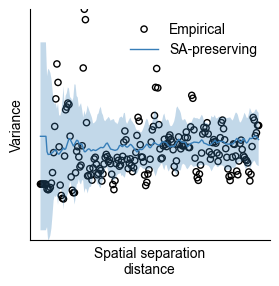

In [76]:
kwargs = {
    'pv': 60,
    'seed': 42,
}

base_fit(
    x=brain_map_TA_L,
    D=D_L,
    nsurr=100,
    nh=200,
    deltas=np.arange(0.5, 1, 0.1),
    resample=False,
    **kwargs
)

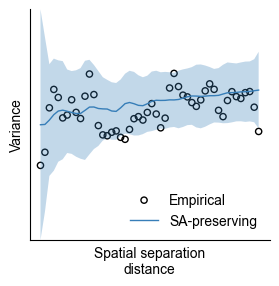

In [77]:
base_fit(x=brain_map_TA_L, D=D_L, nsurr=100,
         deltas=np.arange(0.1, 0.3, 0.05), pv=50, nh=50, resample= False, return_data=False)

In [78]:
x, y, z = base_fit(x=brain_map_TA_L, D=D_L, nsurr=100,
         deltas=np.arange(0.1, 0.3, 0.05), pv=50, nh=50, resample= False, return_data=True)

In [79]:
print("x (bins):", x[:5], "...", x[-5:])
print("y (empirical):", y[:5], "...", y[-5:])
print("z range:", z.min(), z.max())

x (bins): [0.00137689 0.00180132 0.00323633 0.00383042 0.00357118] ... [0.00353839 0.00372639 0.00376243 0.00325654 0.00247287]
y (empirical): [0.2980949  0.37696251 0.45583012 0.53469773 0.61356534] ... [3.84713732 3.92600493 4.00487254 4.08374015 4.16260776]
z range: 1.4440200493505811e-05 0.020951258864126


### SA inpendant vs SA preserving

In [80]:
from brainsmash.mapgen.base import Base
import numpy as np

In [81]:
# calcaulte the pearsonr between surrogate_L of TA and the field fraction of the left hemisphere
from brainsmash.mapgen.stats import pearsonr, pairwise_r

surrogate_brainmap_corrs = pearsonr(brain_map_fieldfrac_L, surrogate_L).flatten()
surrogate_pairwise_corrs = pairwise_r(surrogate_L, flatten=True) # => just to make sure surrogate maps are not too correlated with each other

In [82]:
naive_surrogates = np.array([np.random.permutation(brain_map_TA_L) for _ in range(1000)])
naive_brainmap_corrs = pearsonr(brain_map_fieldfrac_L, naive_surrogates).flatten()
naive_pairwise_corrs = pairwise_r(naive_surrogates, flatten=True)

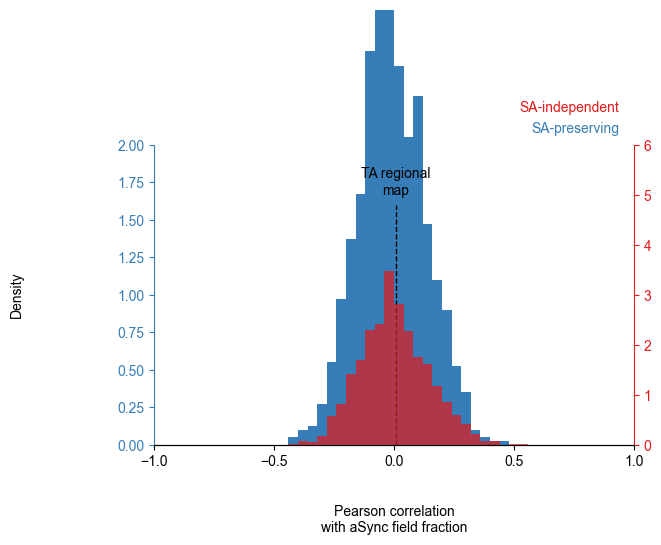

In [83]:
import matplotlib.pyplot as plt
from scipy import stats

sac = '#377eb8'  # autocorr-preserving
rc = '#e41a1c'  # randomly shuffled
bins = np.linspace(-1, 1, 51)  # correlation b

# this is the empirical statistic we're creating a null distribution for
test_stat = stats.pearsonr(brain_map_fieldfrac_L, brain_map_TA_L)[0]

fig = plt.figure(figsize=(8, 5))
ax = fig.add_axes([0.2, 0.25, 0.6, 0.6])  # autocorr preserving
ax2 = ax.twinx()  # randomly shuffled

# plot the data
ax.axvline(test_stat, 0, 0.8, color='k', linestyle='dashed', lw=1)
ax.hist(surrogate_brainmap_corrs, bins=bins, color=sac, alpha=1,
    density=True, clip_on=False, zorder=1)
ax2.hist(naive_brainmap_corrs, bins=bins, color=rc, alpha=0.7,
    density=True, clip_on=False, zorder=2)

# make the plot nice...
ax.set_xticks(np.arange(-1, 1.1, 0.5))
ax.spines['left'].set_color(sac)
ax.tick_params(axis='y', colors=sac)
ax2.spines['right'].set_color(rc)
ax2.tick_params(axis='y', colors=rc)
ax.set_ylim(0, 2)
ax2.set_ylim(0, 6)
ax.set_xlim(-1, 1)
[s.set_visible(False) for s in [
    ax.spines['top'], ax.spines['right'], ax2.spines['top'], ax2.spines['left']]]
ax.text(0.97, 1.1, 'SA-independent', ha='right',va='bottom',
    color=rc, transform=ax.transAxes)
ax.text(0.97, 1.03, 'SA-preserving', ha='right', va='bottom',
    color=sac, transform=ax.transAxes)
ax.text(test_stat, 1.65, "TA regional\nmap", ha='center', va='bottom')
ax.text(0.5, -0.2, "Pearson correlation\nwith aSync field fraction",
    ha='center', va='top', transform=ax.transAxes)
ax.text(-0.3, 0.5, "Density", rotation=90, ha='left', va='center', transform=ax.transAxes)
plt.show()


In [84]:
from brainsmash.mapgen.stats import nonparp

print("Spatially naive p-value:", nonparp(test_stat, naive_brainmap_corrs))
print("SA-corrected p-value:", nonparp(test_stat, surrogate_brainmap_corrs))

Spatially naive p-value: 0.955
SA-corrected p-value: 0.948


In [85]:
def get_centroids(label_list, atlas="/Users/aeed/Documents/Work/Allen_Brain_Atlas/CCF_v3/Atlas_res_50_set_id_3/Atlas_res_50_set_id_3_ROIs_51_bilateral.nii.gz"):
    atlas = nib.load(atlas)
    data = atlas.get_fdata()
    centroids = []
    for label in label_list:
        voxels = np.argwhere(data == label)
        centroid_mni = nib.affines.apply_affine(affine, voxels.mean(axis=0))
        centroids.append(centroid_mni)
    return np.array(centroids)

In [86]:
# encapsulate the above code into a function that takes the two tsv files and the column names to correlate as arguments and returns the p-values
def brainsmash_correlation(tsv_file1: str, tsv_file2: str,
                           col1: str, col2: str,
                           output_dir: Optional[str] = None,
                           output_file_stem: Optional[str] = None,
                           n_surrogates: int = 1000):
    """A function to correlate two columns from two TSV files using the brainsmash method and return the p-values.
    example usage:
    >>> brainsmash_correlation(tsv_file1="/path/to/tsv1.tsv",
                           tsv_file2="/path/to/tsv2.tsv",
                           col1="regional_TA_bilateral",
                           col2="aSync+fieldfrac_bilateral",
                           output_dir="/path/to/output",
                           output_file_stem="brainsmash_correlation",
                           n_surrogates=1000)
    """
    # read the tsv files into dataframes
    df1 = pd.read_csv(tsv_file1, sep="\t")
    df2 = pd.read_csv(tsv_file2, sep="\t")
    # get the atlas and labels
    atlas_51_bilateral = "/Users/aeed/Documents/Work/Allen_Brain_Atlas/CCF_v3/Atlas_res_50_set_id_3/Atlas_res_50_set_id_3_ROIs_51_bilateral.nii.gz"
    atlas_51_bilateral_labels = "/Users/aeed/Documents/Work/Allen_Brain_Atlas/CCF_v3/Atlas_res_50_set_id_3/Atlas_res_50_set_id_3_ROIs_51_bilateral_labels.csv"
    labels_df = pd.read_csv(atlas_51_bilateral_labels, sep=",")
    left_labels = labels_df[labels_df["name"].str.startswith("L_")]["label_value"].values
    right_labels = labels_df[labels_df["name"].str.startswith("R_")]["label_value"].values
    # get the centroids for the left and right hemispheres
    centroids_L = get_centroids(left_labels, atlas=atlas_51_bilateral)
    centroids_R = get_centroids(right_labels, atlas=atlas_51_bilateral)
    # get the distance matrices for the left and right hemispheres
    D_L = cdist(centroids_L, centroids_L)
    D_R = cdist(centroids_R, centroids_R)

    # check if the input_tsv has 'bilateral_region' column, if so, no need to extract the left and right hemisphere values, just use the bilateral values
    if 'bilateral_region' in df1.columns and 'bilateral_region' in df2.columns:
        brain_map1 = df1[col1].values
        brain_map2 = df2[col2].values
    # check has only R_ values, if so, use the right hemisphere values only
    elif df1['name'].str.startswith('R_').all() and df2['name'].str.startswith('R_').all():
        brain_map1 = df1[col1].values
        brain_map2 = df2[col2].values
    else:
        # extract the values for the left hemisphere only
        brain_map1_L = df1[df1['name'].str.startswith('L_')][col1].values
        brain_map1_R = df1[df1['name'].str.startswith('R_')][col1].values
        # take the average of the left and right hemisphere values for brain_map1
        brain_map1 = (brain_map1_L + brain_map1_R) / 2

        brain_map2_L = df2[df2['name'].str.startswith('L_')][col2].values
        brain_map2_R = df2[df2['name'].str.startswith('R_')][col2].values
        # take the average of the left and right hemisphere values for brain_map2
        brain_map2 = (brain_map2_L + brain_map2_R) / 2

    # create the brainsmash base object
    base = Base(x=brain_map1, D=D_R, deltas=np.arange(0.1, 0.3, 0.05), pv=50, nh=50)
    # generate the surrogate maps
    surrogate_R = base(n=n_surrogates)
    # calculate the correlation coefficients for the surrogate maps
    surrogate_brainmap_corrs = pearsonr(brain_map2, surrogate_R).flatten()

    # naive surrogates
    naive_surrogates = np.array([np.random.permutation(brain_map1) for _ in range(n_surrogates)])
    naive_brainmap_corrs = pearsonr(brain_map2, naive_surrogates).flatten()
    # calculate the correlation coefficient for the original maps
    test_stat = stats.pearsonr(brain_map2, brain_map1)[0]
    # calculate the p-values
    p_value_naive = nonparp(test_stat, naive_brainmap_corrs)
    p_value_sa = nonparp(test_stat, surrogate_brainmap_corrs)
    print("Spatially naive p-value:", p_value_naive)
    print("SA-corrected p-value:", p_value_sa)


    # variogram check
    emp_var, u0, surr_var = base_fit(x=brain_map1, D=D_L, nsurr=100,
             deltas=np.arange(0.1, 0.3, 0.05), pv=50, nh=50, resample=False, return_data=True)

    # plot the variogram

    fig, ax = plt.subplots()
    ax.scatter(u0, emp_var, c='k', s=20, zorder=3, label='Empirical')
    ax.plot(u0, surr_var.T, color='steelblue', alpha=0.05)
    ax.fill_between(u0, surr_var.mean(0) - 2*surr_var.std(0),
                    surr_var.mean(0) + 2*surr_var.std(0),
                    color='steelblue', alpha=0.2, label='SA-preserving')
    ax.set_xlabel('Spatial separation distance')
    ax.set_ylabel('Variance')
    ax.legend()
    # save the variogram plot
    output_dir = output_dir or Path(tsv_file1).parent
    output_file_stem = f"brainsmash_variogram_{col1}_{col2}"
    plt.savefig(f"{output_dir}/{output_file_stem}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{output_dir}/{output_file_stem}.pdf", format='pdf', bbox_inches='tight')
    print("Brainsmash variogram plot saved to: ", f"{output_dir}/{output_file_stem}.svg")
    plt.show()

    # plot the correlation distribution
    sac = '#377eb8'  # autocorr-preserving
    rc = '#e41a1c'  # randomly shuffled
    bins = np.linspace(-1, 1, 51)  # correlation b


    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_axes([0.2, 0.25, 0.6, 0.6])  # autocorr preserving
    ax2 = ax.twinx()  # randomly shuffled

    # plot the data
    # plot the data
    ax.axvline(test_stat, 0, 0.8, color='k', linestyle='dashed', lw=1)
    ax.hist(surrogate_brainmap_corrs, bins=bins, color=sac, alpha=1,
        density=True, clip_on=False, zorder=1)
    ax2.hist(naive_brainmap_corrs, bins=bins, color=rc, alpha=0.7,
        density=True, clip_on=False, zorder=2)

    # make the plot nice...
    ax.set_xticks(np.arange(-1, 1.1, 0.5))
    ax.spines['left'].set_color(sac)
    ax.tick_params(axis='y', colors=sac)
    ax2.spines['right'].set_color(rc)
    ax2.tick_params(axis='y', colors=rc)
    ax.set_ylim(0, 4)
    ax2.set_ylim(0, 8)
    ax.set_xlim(-1, 1)
    [s.set_visible(False) for s in [
        ax.spines['top'], ax.spines['right'], ax2.spines['top'], ax2.spines['left']]]
    ax.text(0.97, 1.1, 'SA-independent', ha='right',va='bottom',
        color=rc, transform=ax.transAxes)
    ax.text(0.97, 1.03, 'SA-preserving', ha='right', va='bottom',
        color=sac, transform=ax.transAxes)
    ax.text(test_stat, 1.65, f"{col2}", ha='center', va='bottom')
    ax.text(0.5, -0.2, f"Pearson correlation\nwith {col1}",
        ha='center', va='top', transform=ax.transAxes)
    ax.text(-0.3, 0.5, "Density", rotation=90, ha='left', va='center', transform=ax.transAxes)


    # save the plot
    output_dir = output_dir or Path(tsv_file1).parent
    output_file_stem = f"brainsmash_correlation_{col1}_{col2}"
    plt.savefig(f"{output_dir}/{output_file_stem}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{output_dir}/{output_file_stem}.pdf", format='pdf', bbox_inches='tight')
    print("Brainsmash correlation plot saved to: ", f"{output_dir}/{output_file_stem}.svg")
    plt.show()
    # return the correlation coefficient and the p-values
    return test_stat, p_value_naive, p_value_sa

Spatially naive p-value: 0.437
SA-corrected p-value: 0.454
Brainsmash variogram plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials/brainsmash_variogram_regional_TA_bilateral_aSync+fieldfrac_bilateral.svg


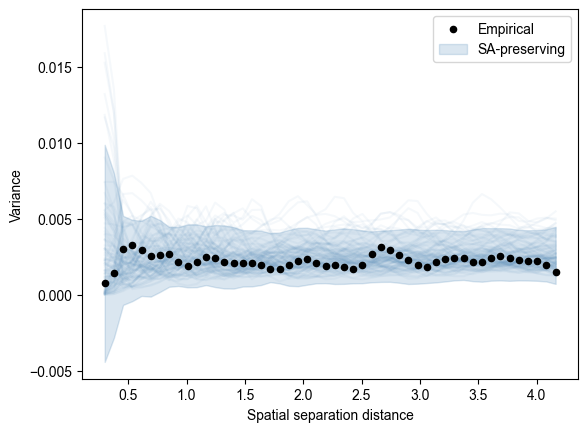

Brainsmash correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials/brainsmash_correlation_regional_TA_bilateral_aSync+fieldfrac_bilateral.svg


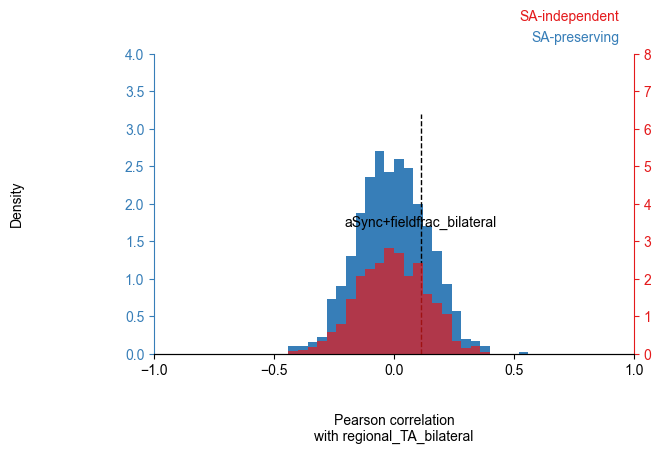

In [87]:
# try the function with the two tsv files and the column names to correlate
TA_tsv = f"{work_dir}/average_regional_TA_bilateral.tsv"
fieldfrac_tsv = f"{work_dir}/sub-hM8362324086031084M5_sample-brain_acq-imaris_seg-mid_from-ABAv3_desc-th800_mergedsegstats_bilateral.tsv"

test_stat, p_value_naive, p_value_sa = brainsmash_correlation(TA_tsv, fieldfrac_tsv, "regional_TA_bilateral", "aSync+fieldfrac_bilateral", n_surrogates=1000)

In [88]:
# wrap the above code into a function that takes two tsv files and the column names to correlate as arguments
def correlate_tsv_columns(tsv_file1: str, tsv_file2: str,
                          col1: str, col2: str,
                          output_dir: Optional[str] = None,
                          output_file_stem: Optional[str] = None,
                          color_vector: Optional[np.ndarray] = None,
                          brainsmash_corr: Optional[float] = None,
                          brainsmash_naive_pval: Optional[float] = None,
                          brainsmash_sa_pval: Optional[float] = None):
    """A function to correlate two columns from two TSV files and plot the correlation.
    example usage:
    >>> correlate_tsv_columns(tsv_file1="/path/to/tsv1.tsv",
                          tsv_file2="/path/to/tsv2.tsv",
                          col1="regional_TA_bilateral",
                          col2="aSync+fieldfrac_bilateral",
                          output_dir="/path/to/output",
                          output_file_stem="correlation_plot",
                          color_vector=None)
    """
    # read the tsv files into dataframes
    df1 = pd.read_csv(tsv_file1, sep="\t")
    df2 = pd.read_csv(tsv_file2, sep="\t")
    if color_vector is None:
        color_vector, legend_names, legend_colors = get_rgb_color_vector(tsv_file1, major_divisions=True)
    # create the plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(df1[col1], df2[col2],
               c=color_vector,
               s=70,
               alpha=0.7,
               edgecolors="black",
               linewidth=1)
    # caclaute the correlation coefficient
    if brainsmash_corr is not None:
        corr_coef = brainsmash_corr
    else:
        corr_coef = np.corrcoef(df1[col1], df2[col2])[0, 1]
    # add the correlation coefficient to the plot
    ax.text(0.95, 0.95, f"r = {corr_coef:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment='top')
    if brainsmash_naive_pval is not None and brainsmash_sa_pval is not None:
        ax.text(0.95, 0.90, f"p (naive) = {brainsmash_naive_pval:.3f}\np (SA) = {brainsmash_sa_pval:.3f}", transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right')
    ax.set_xlabel(col1)
    ax.set_ylabel(col2)
    ax.set_title(f"Correlation between {col1} and {col2}")
    # draw a linear regression line
    m, b = np.polyfit(df1[col1], df2[col2], 1)
    # plot the regression line
    ax.plot(df1[col1], m * df1[col1] + b,
            color='red',
            linestyle="--",
            linewidth=1)
    ax = plt.gca()
    # thicker axes and gray color
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color('gray')
    # thicker ticks
    ax.tick_params(width=2, length=6, labelsize=14, colors='black')
    # bold tick labels
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    # axis labels
    ax.set_xlabel(col1, fontsize=16, fontweight='bold', color='#00538eff')
    ax.set_ylabel(col2, fontsize=16, fontweight='bold', color='#a5141bff')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # use the legend names and colors to create a legend
    handles = [mpatches.Patch(color=rgb, label=legend)
               for legend, rgb in zip(legend_names, legend_colors)]

    plt.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5))



    plt.show()
    # save the plot
    output_dir = output_dir or Path(tsv_file1).parent
    output_file_stem = output_file_stem or f"correlation_{col1}_{col2}"
    plt.savefig(f"{output_dir}/{output_file_stem}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{output_dir}/{output_file_stem}.svg", format='pdf', bbox_inches='tight')
    print("Correlation plot saved to: ", f"{output_dir}/{output_file_stem}.png")
    print(legend_names)
    return corr_coef



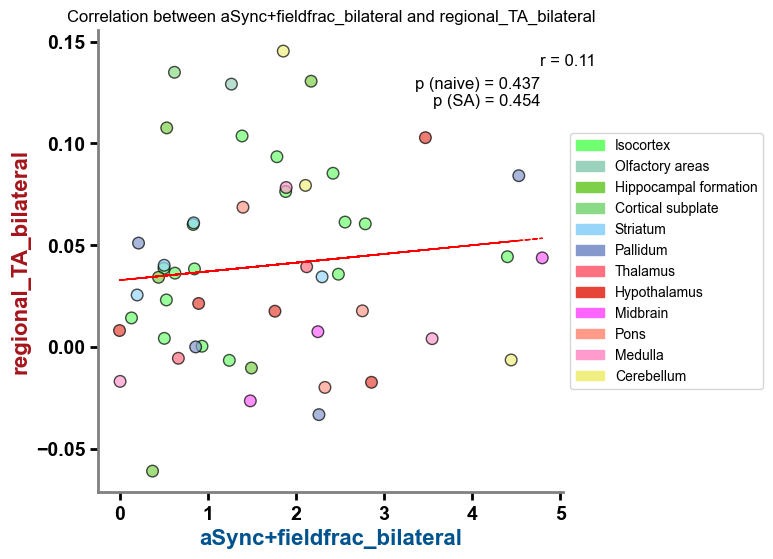

Correlation plot saved to:  /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials/correlation_sync_TA.png
['Isocortex', 'Olfactory areas', 'Hippocampal formation', 'Cortical subplate', 'Striatum', 'Pallidum', 'Thalamus', 'Hypothalamus', 'Midbrain', 'Pons', 'Medulla', 'Cerebellum']


0.11295931495200613

<Figure size 640x480 with 0 Axes>

In [89]:
# try the function with the two tsv files and the column names to correlate
correlate_tsv_columns(sync_tsv, TA_tsv, "aSync+fieldfrac_bilateral", "regional_TA_bilateral",
                      output_file_stem="correlation_sync_TA", color_vector=None, brainsmash_corr=test_stat, brainsmash_naive_pval=p_value_naive, brainsmash_sa_pval=p_value_sa)

# <font color="red">================================subject-wise correlation========================

In [44]:
# take in two lists of tsv files and correlate them and plot the correlation for each subject and save the plots to a directory

In [57]:
metrics_dir = "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/metrics"
dbm_sub_list = glob.glob(f"{metrics_dir}/DBM/sub-*bilateral.tsv")
print(f"{metrics_dir}/DBM")
print(dbm_sub_list)


fieldfraction_sub_list = glob.glob(f"{metrics_dir}/fieldfraction/sub-*bilateral.tsv")
print(fieldfraction_sub_list)

/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/metrics/DBM
['/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/metrics/DBM/sub-hM8362324086031084M5_DBM_bilateral.tsv', '/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/metrics/DBM/sub-hM836323993941035M4_DBM_bilateral.tsv', '/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/metrics/DBM/sub-hM8362334086041083M6_DBM_bilateral.tsv', '/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/metrics/DBM/sub-hM836373993921113M9_DBM_bilateral.tsv', '/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/metrics/DBM/sub-hM8363224086001085M5_DBM_bilateral.tsv']
['/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/metrics/fieldfraction/sub-hM8362324086031084M5_fieldfraction_bilateral.tsv', '/Users/aeed/Documents/Work/M83_

In [58]:
def find(sub_name: str, tsv_list: List[str]) -> Optional[str]:
    """A function to find the TSV file for a given subject name in a list of TSV files.
    example usage:
    >>> find(sub_name="sub-hM8362324086031084M5", tsv_list=["/path/to/sub-hM8362324086031084M5_bilateral.tsv", "/path/to/sub-hM8362324086031084M6_bilateral.tsv"])
    """
    for tsv_file in tsv_list:
        if sub_name in tsv_file:
            return tsv_file
    return None

In [60]:
find("sub-hM8362324086031084M5", dbm_sub_list)

'/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/metrics/fieldfraction/sub-hM8362324086031084M5_fieldfraction_bilateral.tsv'

In [98]:
find("sub-hM8362324086031084M5", fieldfraction_sub_list)

'/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/metrics/fieldfraction/sub-hM8362324086031084M5_fieldfraction_bilateral.tsv'

In [95]:
def correlate_subjectwise_tsv_columns(tsv_list1: List[str],
                                      tsv_list2: List[str],
                                      col1: str,
                                      col2: str,
                                      subject_names: List[str],
                                      output_dir: Optional[str] = None,
                                      output_file_stem: Optional[str] = None,
                                      color_vector: Optional[np.ndarray] = None,
                                      xlim: Optional[list] = None,
                                      ylim: Optional[list] = None):
    """Correlate two columns from two lists of TSV files subject-wise and plot per subject.
    Example:
        >>> correlate_subjectwise_tsv_columns(
        ...     tsv_list1=["/data/TA_sub-01.tsv", "/data/TA_sub-02.tsv"],
        ...     tsv_list2=["/data/aSync_sub-01.tsv", "/data/aSync_sub-02.tsv"],
        ...     col1="regional_TA_bilateral",
        ...     col2="aSync+fieldfrac_bilateral",
        ...     subject_names=["sub-01", "sub-02"],
        ...     output_dir="/results",
        ...     output_file_stem="TA_vs_aSync_correlation",
        ...     xlim=[0, 2],
        ...     ylim=[0, 1],
        ... )

    """
    if len(tsv_list1) != len(tsv_list2):
        raise ValueError("The two lists of TSV files must have the same length.")

    no_subjects = len(subject_names)
    fig, axes = plt.subplots(nrows=1, ncols=no_subjects,
                             figsize=(6 * no_subjects, 6), sharex=True, sharey=True, squeeze=False) # make sure the xlim and ylim are the same for all subplots
    axes = axes[0]  # flatten to 1-D

    legend_names, legend_colors, handles = None, None, []

    for i, subj in enumerate(subject_names):
        tsv_file1 = find(subj, tsv_list1)
        tsv_file2 = find(subj, tsv_list2)
        if tsv_file1 is None or tsv_file2 is None:
            print(f"TSV files for subject {subj} not found.")
            continue

        df1 = pd.read_csv(tsv_file1, sep="\t")
        df2 = pd.read_csv(tsv_file2, sep="\t")
        corr_coef = stats.pearsonr(df1[col1], df2[col2])[0]

        # per-subject colors; don't overwrite the parameter
        if color_vector is None:
            colors, legend_names, legend_colors = get_rgb_color_vector(
                tsv_file1, major_divisions=True)
        else:
            colors = color_vector

        ax = axes[i]
        ax.scatter(df1[col1], df2[col2], c=colors, s=70, alpha=0.7,
                   edgecolors="black", linewidth=1)
        ax.text(0.95, 0.95, f"r = {corr_coef:.3f}", fontsize=12,
                va='top', ha='right', transform=ax.transAxes)
        # ax.set_title(f"Correlation between {col1} and {col2}")

        # single regression line
        m, b = np.polyfit(df1[col1], df2[col2], 1)
        x_line = np.array([df1[col1].min(), df1[col1].max()])
        ax.plot(x_line, m * x_line + b, color='red', linestyle='--', linewidth=1)

        for spine in ax.spines.values():
            spine.set_linewidth(2)
            spine.set_color('gray')
        ax.tick_params(width=2, length=6, labelsize=14, colors='black', labelleft=True) # to show the numbers on the y axis for all subplots
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')
        ax.set_xlabel(col1, fontsize=16, fontweight='bold', color='#00538e')
        ax.set_ylabel(col2, fontsize=16, fontweight='bold', color='#a5141b')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)

    if legend_names is not None:
        handles = [mpatches.Patch(color=rgb, label=name)
                   for name, rgb in zip(legend_names, legend_colors)]
        legend = fig.legend(handles=handles, loc='center left',
                            bbox_to_anchor=(0.92, 0.5), frameon=True)
        legend.get_frame().set_edgecolor('black')
        legend.get_frame().set_linewidth(1.5)

    output_dir = output_dir or Path(tsv_list1[0]).parent
    output_file_stem = output_file_stem or f"subjectwise_correlation_{col1}_{col2}"
    fig.savefig(f"{output_dir}/{output_file_stem}.svg", format='svg', bbox_inches='tight')
    fig.savefig(f"{output_dir}/{output_file_stem}.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    print(f"Saved to {output_dir}/{output_file_stem}.svg / .pdf")

In [96]:
# give it a try with the two lists of tsv files and the column names to correlate
pff_subjects = [
    "sub-hM8362334086041083M6",
    "sub-hM836323993941035M4",
    "sub-hM8363224086001085M5",
    "sub-hM836373993921113M9",
    "sub-hM8362324086031084M5",
]

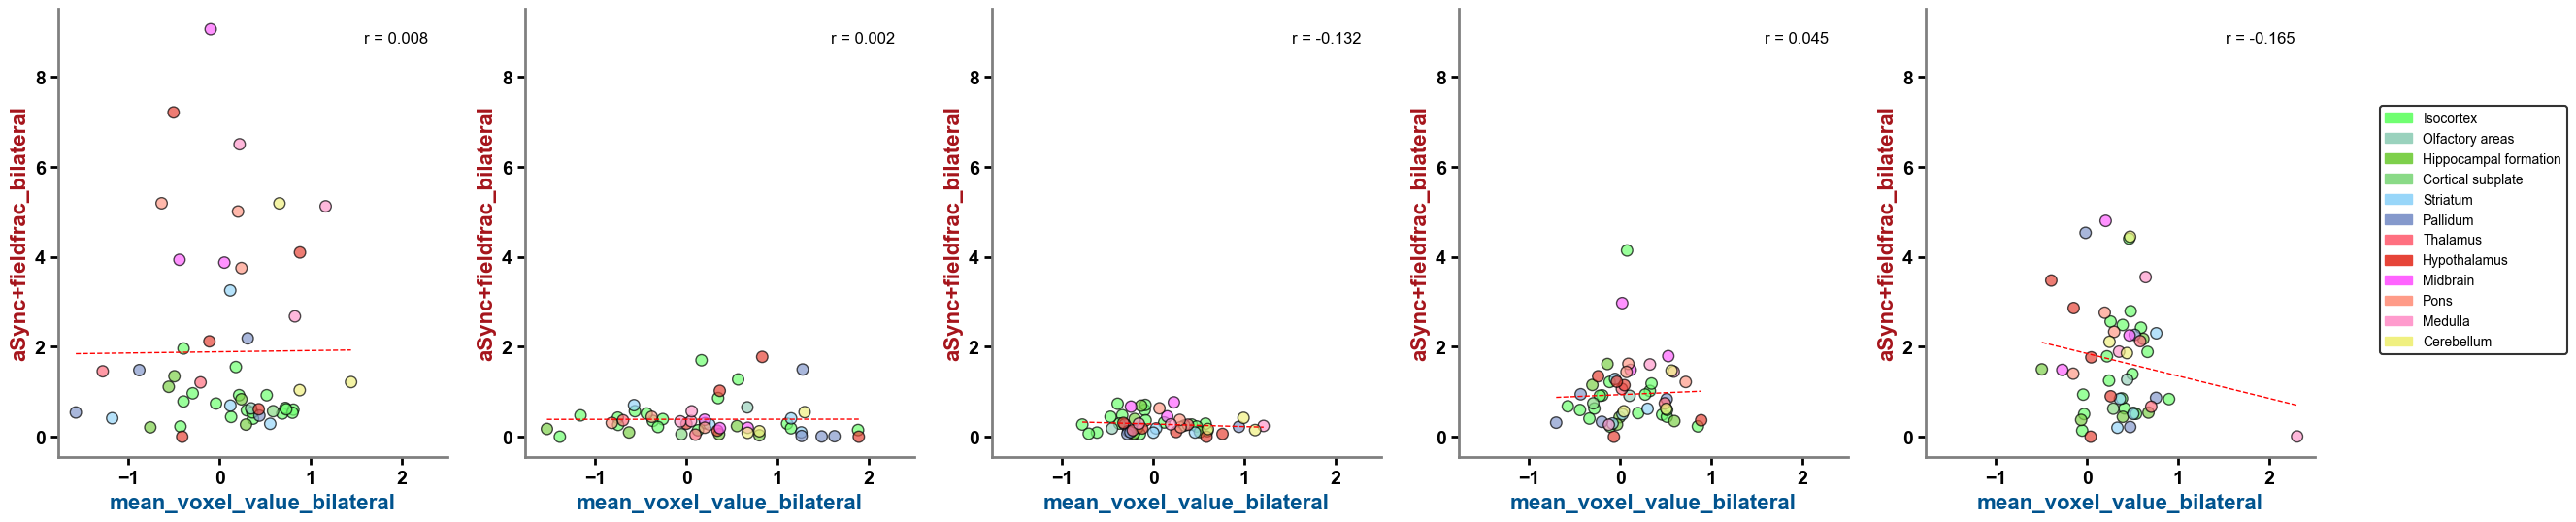

Saved to /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials/subjectwise_correlation_sync_TA.svg / .pdf


In [97]:
# correlate the two lists of tsv files and the column names to correlate
from correlation_functions import get_rgb_color_vector
correlate_subjectwise_tsv_columns(dbm_sub_list, fieldfraction_sub_list,
                                  col1="mean_voxel_value_bilateral",
                                  col2="aSync+fieldfrac_bilateral",
                                  subject_names=pff_subjects,
                                  output_dir="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials",
                                  output_file_stem="subjectwise_correlation_sync_TA")

# <font color="red">================================a function to create subject-wise tsv from single tsv like stuc conn========================

In [99]:
tsv_file = "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/metrics/struc_conn/CP_avg_conn_right_positive_str_log10.tsv"

In [100]:
pff_subjects

['sub-hM8362334086041083M6',
 'sub-hM836323993941035M4',
 'sub-hM8363224086001085M5',
 'sub-hM836373993921113M9',
 'sub-hM8362324086031084M5']

In [106]:
for subj in pff_subjects:
    df = pd.read_csv(tsv_file, sep="\t")
    # get tsv file stem
    tsv_file_stem = Path(tsv_file).stem
    output_file = f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/BrainSMASH_correlations/functions_trials/{subj}_{tsv_file_stem}.tsv"
    shutil.copy2(tsv_file, output_file)



In [107]:
Path(tsv_file).stem

'CP_avg_conn_right_positive_str_log10'

In [ ]:
# wrap into a function with an option to use the same output directory or a different one
def create_subjectwise_tsv(tsv_file: str,
                           subject_names: List[str],
                           output_dir: Optional[str] = None):
    """Create subject-wise TSV files from a single TSV file by copying the original TSV file and renaming it for each subject.
    Example:
        >>> create_subjectwise_tsv(tsv_file="/data/CP_avg_conn_right_positive_str_log10.tsv",
        ...     subject_names=["sub-01", "sub-02"],
        ...     output_dir="/results",
        ...     same_output_dir=True)
    """
    output_dir = output_dir or Path(tsv_file).parent
    for subj in subject_names:
        # get tsv file stem
        tsv_file_stem = Path(tsv_file).stem

        output_file = f"{output_dir}/{subj}_{tsv_file_stem}.tsv"
        shutil.copy2(tsv_file, output_file)
